### Importing Libraries
- pandas: For data manipulation and analysis.
- numpy: For numerical operations.
- train_test_split: To split the data into training and testing sets.
- KNeighborsClassifier: The KNN Classifier model from scikit-learn.
- classification_report: To evaluate precision, recall, f1-score, etc.
- confusion_matrix: To get a confusion matrix for the model evaluation.
- matplotlib and seaborn: For visualization.

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier 
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

### Loading and Preparing the Data
- pd.read_csv(): Reads the Titanic dataset.
- data.info(): Provides a summary of the dataset, including the presence of missing values.
- data.head(): Shows the first few rows of the dataset.
- fillna(): Fills missing values in the 'Age' and 'Embarked' columns.
- map(): Converts categorical variables ('Sex' and 'Embarked') to numerical values.
- drop(): Removes columns that won't be used for the model.

In [4]:
data = pd.read_csv('Titanic Data.csv')

In [5]:
# Display basic information
print(data.info())
print(data.head())

# Fill missing values
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Convert categorical columns to numeric
data['Sex'] = data['Sex'].map({'male': 0, 'female': 1})
data['Embarked'] = data['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

# Drop unnecessary columns
data.drop(['Name', 'Ticket', 'Cabin'], axis=1, inplace=True)

# Display cleaned data
print(data.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB
None
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                      

### Splitting the Data
- data.drop('Survived', axis=1): Drops the target column to create feature set X.
- data['Survived']: The target variable y.
- train_test_split(): Splits the data into training and testing sets, with 30% for testing.

In [6]:
# Define features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

### Training the Model
- LogisticRegression(): Initializes the logistic regression model.
- model.fit(): Trains the model on the training data.

In [7]:
# Create a logistic regression model
model = KNeighborsClassifier(n_neighbors=3)

# Train the model
model.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

### Choosing K for KNN

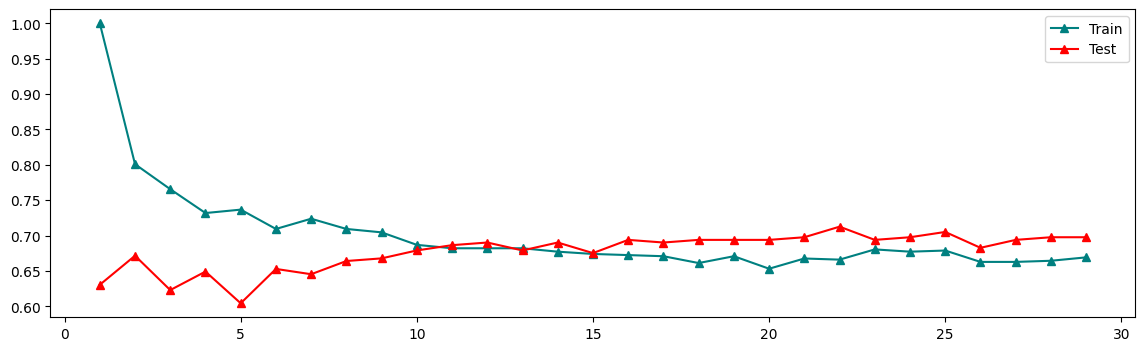

In [8]:
train_acc = []
test_acc = []

for i in range(1,30):
    model_knn = KNeighborsClassifier(n_neighbors=i)
    model_knn.fit(X_train,y_train)
    train_acc.append(model_knn.score(X_train,y_train))
    test_acc.append(model_knn.score(X_test,y_test))

plt.figure(figsize=(14,4))
plt.plot(range(1,30),train_acc,marker="^",color='teal',label="Train")
plt.plot(range(1,30),test_acc,marker="^",color='red',label="Test")
plt.legend()
plt.show()

In [9]:
# based on above we can choose K =10 as it gives best fitted model without any overfitting

# Create a logistic regression model
model = KNeighborsClassifier(n_neighbors=10)

# Train the model
model.fit(X_train, y_train)


KNeighborsClassifier(n_neighbors=10)

### Making Predictions and Evaluating the Model
- model.predict(): Makes predictions on the test set.
- classification_report(): Provides a detailed report of precision, recall, f1-score, etc.
- confusion_matrix(): Computes the confusion matrix.
- sns.heatmap(): Visualizes the confusion matrix using a heatmap for better interpretation.

              precision    recall  f1-score   support

           0       0.69      0.90      0.78       381
           1       0.69      0.36      0.47       242

    accuracy                           0.69       623
   macro avg       0.69      0.63      0.62       623
weighted avg       0.69      0.69      0.66       623



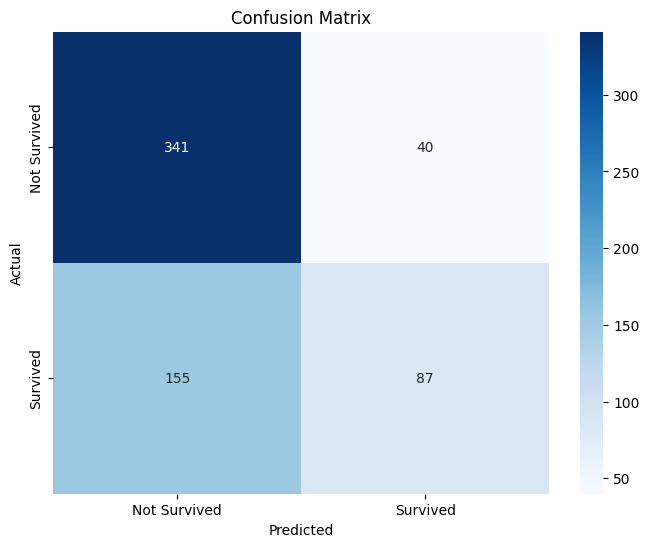

              precision    recall  f1-score   support

           0       0.69      0.89      0.78       168
           1       0.63      0.33      0.43       100

    accuracy                           0.68       268
   macro avg       0.66      0.61      0.61       268
weighted avg       0.67      0.68      0.65       268



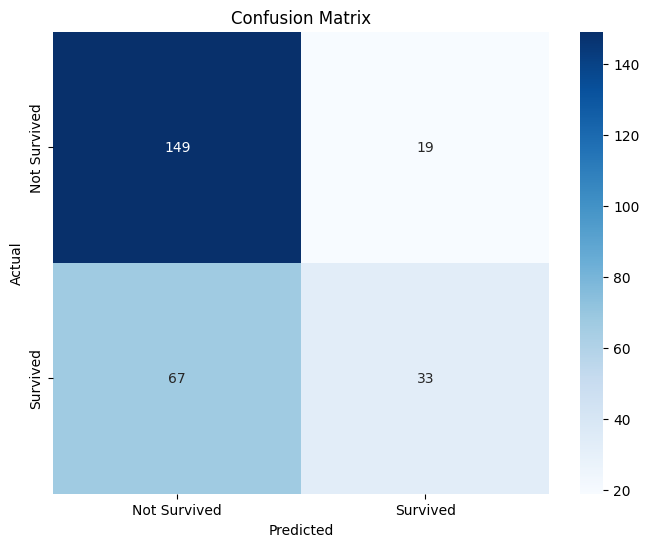

In [10]:
# Make predictions for train data
y_train_pred = model.predict(X_train)

# Generate the classification report
print(classification_report(y_train, y_train_pred))

# Generate the confusion matrix
cm = confusion_matrix(y_train, y_train_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()



# Make predictions for test data
y_pred = model.predict(X_test)

# Generate the classification report
print(classification_report(y_test, y_pred))

# Generate the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Visualize the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Not Survived', 'Survived'], yticklabels=['Not Survived', 'Survived'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()